🔄 Loading data for Ostrava-Svinov...
   -> Found train data headers at Row 5
    [DEBUG] Train File Columns found: ['název bodu výběru', 'číslo vlaku', 'druh vlaku', 'název výchozí stanice vlaku', 'název cílové stanice vlaku', 'čas příjezdu', 'čas odjezdu']
   -> Train columns standardized successfully.
✅ Data Loaded.
⚡ Generating Train Signals...
🚲 Calculating Bike Flows...
🎨 Plotting...


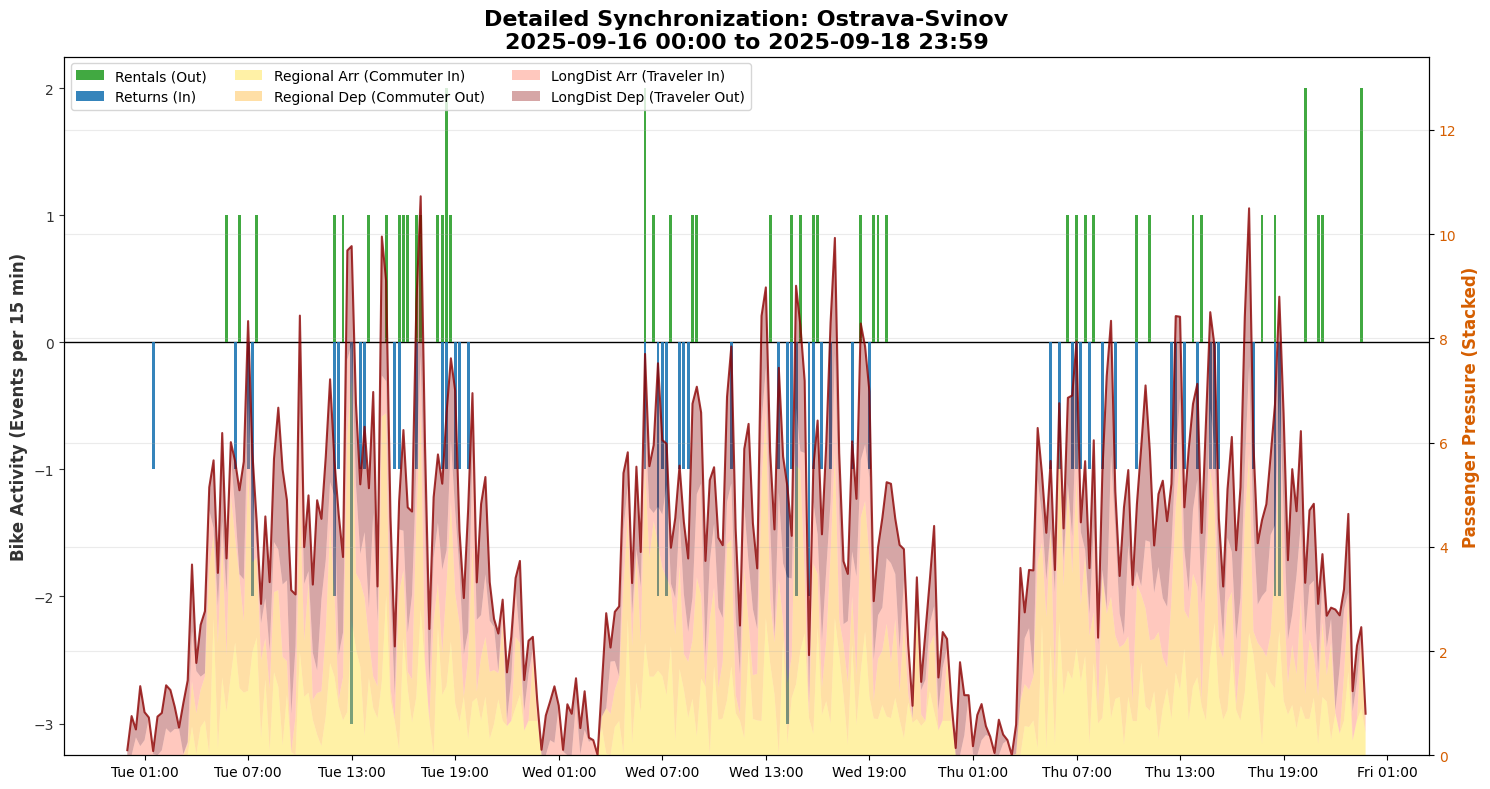

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import transport_analytics as ta  # Ensure this file is in the same folder
import numpy as np

# ==========================================
# 1. CONFIGURATION (Edit this part)
# ==========================================
CITY_KEY = 'Ostrava-Svinov'
# Choose a 2-3 day window for best visibility
VIS_START = '2025-09-16 00:00'
VIS_END = '2025-09-18 23:59'

# Define your file paths (Update these to point to your files)
FILE_TRAINS = 'data/Pohyby_Svinov.xlsx'
FILE_BIKES = 'data/nextbike_data_VSB_Vaclavik.xlsx'
SHEET_RENTALS = 'Vypujcky_Ostrava'

# Station Definitions
STATION_CONFIG = {
    'train_station': 'Ostrava-Svinov',
    'bike_stations': ['SV-Svinov nádraží *(navíc 15min na odjezd)'],
    'params': { # Standard weights
        'weights': {'Os': 2.0, 'Sp': 1.7, 'R': 1.5, 'Ex': 1},
        'peak_arr_reg': 2, 'pulse_arr_reg': 15,
        'peak_arr_ld': 5, 'pulse_arr_ld': 20,
        'peak_dep_reg': 8, 'pulse_dep_reg': 20,
        'peak_dep_ld': 15, 'pulse_dep_ld': 35
    }
}

# ==========================================
# 2. DATA LOADING & PROCESSING (Fixed Header Detection)
# ==========================================
print(f"🔄 Loading data for {CITY_KEY}...")

# --- 1. SMART LOAD TRAINS (Find Header Row) ---
# First, look at the first 20 rows to find where the table actually starts
df_preview = pd.read_excel(FILE_TRAINS, header=None, nrows=20)
header_idx = 0 # Default

for idx, row in df_preview.iterrows():
    # Convert row to string and check for keywords like 'čas' (time) or 'druh' (type)
    row_str = row.astype(str).str.lower().values
    if any('čas' in x or 'cas' in x or 'druh' in x for x in row_str):
        header_idx = idx
        break

print(f"   -> Found train data headers at Row {header_idx + 1}")

# Now load properly using the found header row
df_trains = pd.read_excel(FILE_TRAINS, header=header_idx)

# Clean and Standardize
df_trains = ta.standard_columns(df_trains)

# Verify success
if 'actual_arrival' not in df_trains.columns:
    print("❌ ERROR: Column 'actual_arrival' still missing!")
    print("   Found columns:", df_trains.columns.tolist())
    raise KeyError("Train file format not recognized. Check column names.")
else:
    print("   -> Train columns standardized successfully.")

# --- 2. LOAD BIKES ---
df_bikes = pd.read_excel(FILE_BIKES, sheet_name=SHEET_RENTALS)
df_bikes.columns = [str(c).lower().strip() for c in df_bikes.columns]
df_bikes['start_time'] = pd.to_datetime(df_bikes['start_time'])
df_bikes['end_time'] = pd.to_datetime(df_bikes['end_time'])

# --- 3. SETUP TIMELINE ---
zoom_start = pd.to_datetime(VIS_START)
zoom_end = pd.to_datetime(VIS_END)
timeline_1min = pd.date_range(zoom_start, zoom_end, freq='1min')
timeline_15min = pd.date_range(zoom_start, zoom_end, freq='15min')

print("✅ Data Loaded.")
# ==========================================
# 3. GENERATE SEPARATE SIGNALS
# ==========================================
print("⚡ Generating Train Signals...")

# Filter Trains to Window
t_mask = (df_trains['actual_arrival'] >= zoom_start) & (df_trains['actual_arrival'] <= zoom_end)
zoom_trains = df_trains[t_mask].copy()

# Split into Categories
regional_types = ['Os', 'Sp']
ld_types = ['R', 'Ex', 'IC', 'EC', 'SC', 'rj']

df_reg = zoom_trains[zoom_trains['train_type'].isin(regional_types)]
df_ld = zoom_trains[zoom_trains['train_type'].isin(ld_types)]

# Generate 4 Separate Signals (Arr/Dep for each)
s_arr_reg, s_dep_reg = ta.generate_signals(df_reg, timeline_1min, STATION_CONFIG['params'])
s_arr_ld, s_dep_ld = ta.generate_signals(df_ld, timeline_1min, STATION_CONFIG['params'])

# Resample to 15min for cleaner plotting
sig_reg_arr = s_arr_reg.resample('15min').mean()
sig_reg_dep = s_dep_reg.resample('15min').mean()
sig_ld_arr = s_arr_ld.resample('15min').mean()
sig_ld_dep = s_dep_ld.resample('15min').mean()

# ==========================================
# 4. CALCULATE BIKE FLOWS
# ==========================================
print("🚲 Calculating Bike Flows...")
starts = df_bikes[df_bikes['start_place'].isin(STATION_CONFIG['bike_stations'])]
ends = df_bikes[df_bikes['end_place'].isin(STATION_CONFIG['bike_stations'])]

ts_rentals = starts.set_index('start_time').resample('15min').size().reindex(timeline_15min, fill_value=0)
ts_returns = ends.set_index('end_time').resample('15min').size().reindex(timeline_15min, fill_value=0) * -1

# ==========================================
# 5. VISUALIZATION
# ==========================================
print("🎨 Plotting...")
fig, ax1 = plt.subplots(figsize=(15, 8))

# --- LAYER 1: BIKE FLOWS (Bars) ---
# Z-order 3 puts bars on TOP of the area chart
ax1.bar(timeline_15min, ts_rentals, width=0.007, color='#2ca02c', alpha=0.9, label='Rentals (Out)', align='center', zorder=3)
ax1.bar(timeline_15min, ts_returns, width=0.007, color='#1f77b4', alpha=0.9, label='Returns (In)', align='center', zorder=3)

ax1.axhline(0, color='black', linewidth=1)
ax1.set_ylabel('Bike Activity (Events per 15 min)', fontsize=12, fontweight='bold', color='#333333')
ax1.tick_params(axis='y', colors='#333333')

# --- LAYER 2: TRAIN PRESSURE (Stacked Area) ---
ax2 = ax1.twinx()

# Data for stackplot
x = timeline_15min
y_stack = [sig_reg_arr, sig_reg_dep, sig_ld_arr, sig_ld_dep]
labels = ['Regional Arr (Commuter In)', 'Regional Dep (Commuter Out)', 'LongDist Arr (Traveler In)', 'LongDist Dep (Traveler Out)']

# Distinct Colors: Gold/Orange for Regional, Red/DarkRed for Long Distance
colors = ['#FFD700', '#FFA500', '#FF6347', '#8B0000']

ax2.stackplot(x, y_stack, labels=labels, colors=colors, alpha=0.35, zorder=1)

# Outline for total pressure
total_pressure = sum(y_stack)
ax2.plot(x, total_pressure, color='#8B0000', linewidth=1.5, alpha=0.8, zorder=2, label='Total Pressure')

ax2.set_ylabel('Passenger Pressure (Stacked)', fontsize=12, fontweight='bold', color='#d55e00')
ax2.tick_params(axis='y', labelcolor='#d55e00')

# Scaling: Add headroom
if not total_pressure.empty:
    ax2.set_ylim(0, total_pressure.max() * 1.25)

# --- FORMATTING ---
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%a %H:%M'))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.title(f"Detailed Synchronization: {CITY_KEY}\n{VIS_START} to {VIS_END}", fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.25)

# Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# Skip the 'Total Pressure' line in legend to keep it clean, or keep it if you prefer
ax1.legend(lines1 + lines2[:4], labels1 + labels2[:4], loc='upper left', ncol=3, frameon=True, fontsize=10)

plt.tight_layout()
plt.show()